# Crop Pest LightGBM Classifier
Multi-feature fusion: HSV Histogram + Hu Moments + LBP + HOG + Contour Geometry + GLCM Haralick

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import os
import pickle
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb

from shared import (
    resolve_paths, yolo_box_to_xyxy, clamp_xyxy,
    plot_confusion_matrix, save_classification_report,
)
from feature_extraction import extract_features, create_hog_descriptor

PROJECT_ROOT, DATA_ROOT, OUT_ROOT = resolve_paths()

FEATURE_CACHE_DIR = Path(OUT_ROOT) / "lightgbm_cache"
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT: f:\github\agro-pest
DATA_ROOT:    f:\github\agro-pest\archive
OUT_ROOT:     f:\github\agro-pest\runs
Data exists:  True


In [8]:
CONFIG = {
    "YOLO_ROOT": DATA_ROOT,
    "OUT_ROOT": OUT_ROOT,

    "CLASS_NAMES": [
        "Ants", "Bees", "Beetles", "Caterpillars", "Earthworms", "Earwigs",
        "Grasshoppers", "Moths", "Slugs", "Snails", "Wasps", "Weevils",
    ],

    "CROP_MARGIN_RATIO": 0.05,
    "MIN_CROP_SIZE": 20,
    "RESIZE_TO": (64, 64),

    "LGBM_NUM_LEAVES": 31,
    "LGBM_MAX_DEPTH": -1,
    "LGBM_LEARNING_RATE": 0.05,
    "LGBM_N_ESTIMATORS": 500,
    "LGBM_SUBSAMPLE": 0.8,
    "LGBM_COLSAMPLE_BYTREE": 0.8,
    "LGBM_REG_ALPHA": 0.1,
    "LGBM_REG_LAMBDA": 0.1,
    "LGBM_MIN_CHILD_SAMPLES": 20,
    "LGBM_EARLY_STOPPING": 50,
    "LGBM_VERBOSE_EVAL": 50,
}

cfg = CONFIG

In [9]:
def load_paths(folder):
    images_folder = os.path.join(folder, "images")
    labels_folder = os.path.join(folder, "labels")
    image_paths = sorted(
        [os.path.join(images_folder, f) for f in os.listdir(images_folder)]
    )
    label_paths = sorted(
        [os.path.join(labels_folder, f) for f in os.listdir(labels_folder)]
    )
    return image_paths, label_paths


def extract_dataset_features(image_paths, label_paths, hog_desc, margin_ratio=0.05, min_crop=20, resize_to=(64, 64), desc="Extracting"):
    X = []
    y = []
    for img_path, label_path in tqdm(zip(image_paths, label_paths), total=len(image_paths), desc=desc):
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]
        with open(label_path, "r") as f:
            lines = [ln for ln in f.read().strip().splitlines() if ln.strip()]
        for line in lines:
            cid, xyxy = yolo_box_to_xyxy(line, W, H)
            if cid is None or xyxy is None:
                continue
            xyxy = clamp_xyxy(xyxy, W, H, margin_ratio=margin_ratio)
            if xyxy is None:
                continue
            x1, y1, x2, y2 = xyxy
            roi = img[y1:y2, x1:x2]
            if roi.size == 0 or roi.shape[0] < min_crop or roi.shape[1] < min_crop:
                continue
            roi = cv2.resize(roi, resize_to)
            feature = extract_features(roi, hog_desc)
            X.append(feature)
            y.append(cid)
        del img
    return np.array(X), np.array(y)


def save_features(cache_path, X, y):
    data = {"X": X, "y": y}
    with open(cache_path, "wb") as f:
        pickle.dump(data, f)
    print(f"Features saved to {cache_path}")


def load_features(cache_path):
    with open(cache_path, "rb") as f:
        data = pickle.load(f)
    print(f"Features loaded from {cache_path}")
    return data.get("X"), data.get("y")

In [10]:
USE_CACHE = True
cache_file = FEATURE_CACHE_DIR / "train_features.pkl"

if USE_CACHE and cache_file.exists():
    X_train, y_train = load_features(cache_file)
    hog_desc = create_hog_descriptor()
else:
    train_folder = os.path.join(cfg["YOLO_ROOT"], "train")
    train_image_paths, train_label_paths = load_paths(train_folder)
    hog_desc = create_hog_descriptor()
    X_train, y_train = extract_dataset_features(
        train_image_paths, train_label_paths, hog_desc,
        margin_ratio=cfg["CROP_MARGIN_RATIO"],
        min_crop=cfg["MIN_CROP_SIZE"],
        resize_to=cfg["RESIZE_TO"],
        desc="Train",
    )
    save_features(cache_file, X_train, y_train)

print(f"Training samples: {len(X_train)}, Feature dim: {X_train.shape[1]}")

unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

Features loaded from f:\github\agro-pest\runs\lightgbm_cache\train_features.pkl
Training samples: 15255, Feature dim: 16468
Class distribution: {0: 2221, 1: 1592, 2: 1058, 3: 1733, 4: 1083, 5: 1182, 6: 1071, 7: 1062, 8: 918, 9: 1196, 10: 1167, 11: 972}


In [11]:
from sklearn.model_selection import train_test_split
import joblib

USE_CACHE = True
model_cache_file = FEATURE_CACHE_DIR / "lightgbm_model.pkl"

if USE_CACHE and model_cache_file.exists():
    cached_data = joblib.load(model_cache_file)
    if isinstance(cached_data, tuple) and len(cached_data) == 2:
        model, scaler = cached_data
        print(f"Model loaded from {model_cache_file}")
    else:
        os.remove(model_cache_file)
        print(f"Deleted old cache file {model_cache_file}, will retrain...")
        cached_data = None
else:
    cached_data = None

if cached_data is None:
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
    )
    print(f"Train split: {len(X_train_split)}, Val split: {len(X_val)}")

    scaler = StandardScaler()
    X_train_split = scaler.fit_transform(X_train_split)
    X_val = scaler.transform(X_val)

    model = lgb.LGBMClassifier(
        n_estimators=cfg["LGBM_N_ESTIMATORS"],
        learning_rate=cfg["LGBM_LEARNING_RATE"],
        num_leaves=cfg["LGBM_NUM_LEAVES"],
        max_depth=cfg["LGBM_MAX_DEPTH"],
        subsample=cfg["LGBM_SUBSAMPLE"],
        colsample_bytree=cfg["LGBM_COLSAMPLE_BYTREE"],
        reg_alpha=cfg["LGBM_REG_ALPHA"],
        reg_lambda=cfg["LGBM_REG_LAMBDA"],
        min_child_samples=cfg["LGBM_MIN_CHILD_SAMPLES"],
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )

    model.fit(
        X_train_split, y_train_split,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(cfg["LGBM_EARLY_STOPPING"]),
            lgb.log_evaluation(cfg["LGBM_VERBOSE_EVAL"]),
        ],
    )
    print("LightGBM training complete")

    joblib.dump((model, scaler), model_cache_file)
    print(f"Model saved to {model_cache_file}")

Deleted old cache file f:\github\agro-pest\runs\lightgbm_cache\lightgbm_model.pkl, will retrain...
Train split: 12966, Val split: 2289
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 1.31715
[100]	valid_0's multi_logloss: 1.09943
[150]	valid_0's multi_logloss: 0.990497
[200]	valid_0's multi_logloss: 0.93103
[250]	valid_0's multi_logloss: 0.897419
[300]	valid_0's multi_logloss: 0.880076
[350]	valid_0's multi_logloss: 0.87089
[400]	valid_0's multi_logloss: 0.867571
[450]	valid_0's multi_logloss: 0.866017
[500]	valid_0's multi_logloss: 0.866323
Did not meet early stopping. Best iteration is:
[463]	valid_0's multi_logloss: 0.865148
LightGBM training complete
Model saved to f:\github\agro-pest\runs\lightgbm_cache\lightgbm_model.pkl


Features loaded from f:\github\agro-pest\runs\lightgbm_cache\test_features.pkl
Test samples: 689
Test accuracy: 0.5747
              precision    recall  f1-score   support

        Ants     0.5045    0.6437    0.5657        87
        Bees     0.5846    0.8636    0.6972        44
     Beetles     0.3548    0.2500    0.2933        44
Caterpillars     0.4963    0.7204    0.5877        93
  Earthworms     0.5641    0.5500    0.5570        40
     Earwigs     0.4359    0.2329    0.3036        73
Grasshoppers     0.5814    0.4545    0.5102        55
       Moths     0.7949    0.6596    0.7209        47
       Slugs     0.6400    0.3137    0.4211        51
      Snails     0.6271    0.7400    0.6789        50
       Wasps     0.6939    0.7234    0.7083        47
     Weevils     0.7778    0.7241    0.7500        58

    accuracy                         0.5747       689
   macro avg     0.5879    0.5730    0.5662       689
weighted avg     0.5759    0.5747    0.5603       689



d:\python-3.11\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


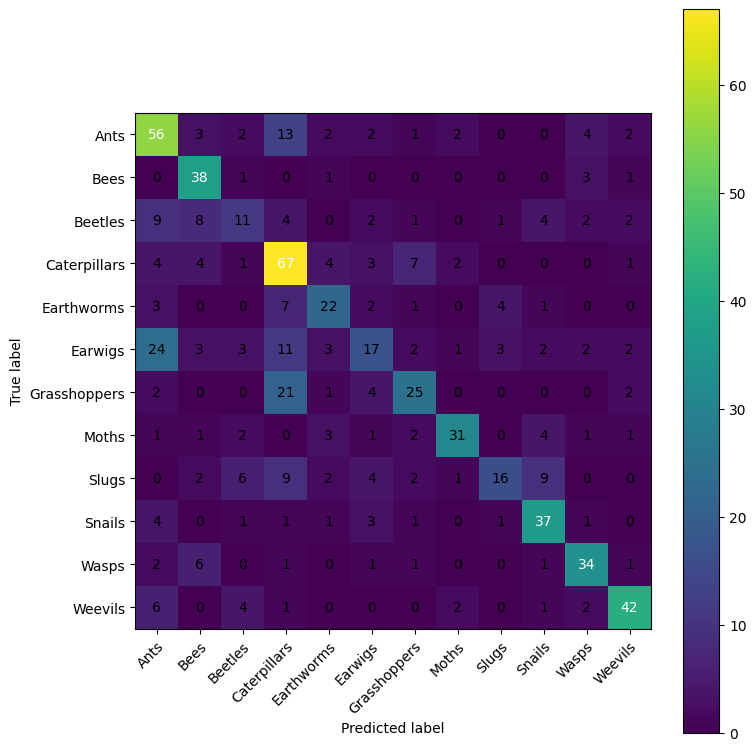


=== DONE (LightGBM) ===


In [12]:
USE_CACHE = True
cache_file_test = FEATURE_CACHE_DIR / "test_features.pkl"

if USE_CACHE and cache_file_test.exists():
    X_test, y_test = load_features(cache_file_test)
else:
    test_folder = os.path.join(cfg["YOLO_ROOT"], "test")
    test_image_paths, test_label_paths = load_paths(test_folder)
    X_test, y_test = extract_dataset_features(
        test_image_paths, test_label_paths, hog_desc,
        margin_ratio=cfg["CROP_MARGIN_RATIO"],
        min_crop=cfg["MIN_CROP_SIZE"],
        resize_to=cfg["RESIZE_TO"],
        desc="Test",
    )
    save_features(cache_file_test, X_test, y_test)

print(f"Test samples: {len(X_test)}")

X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=cfg["CLASS_NAMES"], digits=4))

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, cfg["CLASS_NAMES"], os.path.join(cfg["OUT_ROOT"], "lightgbm_cm_test.png"))

save_classification_report(
    Path(cfg["OUT_ROOT"]), y_test, y_pred, cfg["CLASS_NAMES"]
)

print("\n=== DONE (LightGBM) ===")

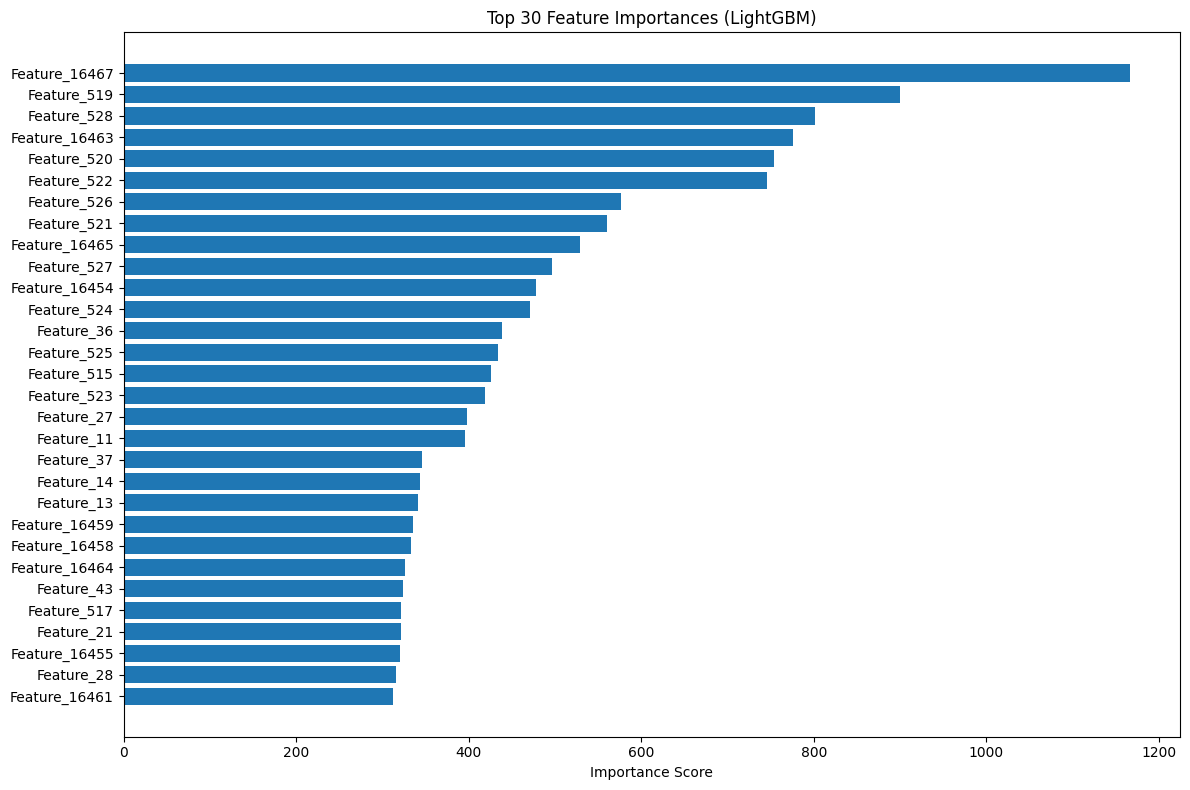

Top 30 important features:
  1. Feature_16467: 1166.00
  2. Feature_519: 900.00
  3. Feature_528: 801.00
  4. Feature_16463: 776.00
  5. Feature_520: 754.00
  6. Feature_522: 746.00
  7. Feature_526: 577.00
  8. Feature_521: 560.00
  9. Feature_16465: 529.00
  10. Feature_527: 497.00
  11. Feature_16454: 478.00
  12. Feature_524: 471.00
  13. Feature_36: 438.00
  14. Feature_525: 434.00
  15. Feature_515: 426.00
  16. Feature_523: 419.00
  17. Feature_27: 398.00
  18. Feature_11: 396.00
  19. Feature_37: 346.00
  20. Feature_14: 344.00
  21. Feature_13: 341.00
  22. Feature_16459: 335.00
  23. Feature_16458: 333.00
  24. Feature_16464: 326.00
  25. Feature_43: 324.00
  26. Feature_517: 322.00
  27. Feature_21: 321.00
  28. Feature_16455: 320.00
  29. Feature_28: 316.00
  30. Feature_16461: 312.00


In [13]:
import matplotlib.pyplot as plt

feature_importance = model.feature_importances_
feature_names = [f"Feature_{i}" for i in range(len(feature_importance))]

top_n = 30
indices = np.argsort(feature_importance)[::-1][:top_n]

plt.figure(figsize=(12, 8))
plt.title(f"Top {top_n} Feature Importances (LightGBM)")
plt.barh(range(top_n), feature_importance[indices], align="center")
plt.yticks(range(top_n), [feature_names[i] for i in indices])
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(cfg["OUT_ROOT"], "lightgbm_feature_importance.png"), dpi=200)
plt.show()

print(f"Top {top_n} important features:")
for i, idx in enumerate(indices):
    print(f"  {i+1}. {feature_names[idx]}: {feature_importance[idx]:.2f}")